## 1. Objective

This notebook evaluates selected relationships identified during the exploratory analysis using formal statistical tests.

The purpose is to determine whether observed differences or associations in the dataset are supported by statistical evidence rather than relying only on visual patterns or descriptive statistics.

The analysis focuses on relationships that are relevant to the defined business questions and suitable for statistical testing.    

## 2. Load Analytical Dataset

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# stats
import pingouin as pg
from scipy.stats import spearmanr
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [6]:
df = pd.read_csv("../data/processed/trendOne_clean.csv")
df.shape

(3900, 21)

In [7]:
df.head()

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount_usd,location,region,size,...,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,previous_purchases_group,payment_method,frequency_of_purchases
0,1,55,55-64,Male,Blouse,Clothing,53,Kentucky,South,L,...,Winter,3.1,Yes,Express,Yes,Yes,14,11-20,Venmo,Fortnightly
1,2,19,18-24,Male,Sweater,Clothing,64,Maine,Northeast,L,...,Winter,3.1,Yes,Express,Yes,Yes,2,0-5,Cash,Fortnightly
2,3,50,45-54,Male,Jeans,Clothing,73,Massachusetts,Northeast,S,...,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,21+,Credit Card,Weekly
3,4,21,18-24,Male,Sandals,Footwear,90,Rhode Island,Northeast,M,...,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,21+,PayPal,Weekly
4,5,45,45-54,Male,Blouse,Clothing,49,Oregon,West,M,...,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,21+,PayPal,Annually


In [8]:
df.tail()

,customer_id,age,age_group,gender,item_purchased,category,purchase_amount_usd,location,region,size,...,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,previous_purchases_group,payment_method,frequency_of_purchases
3895,3896,40,35-44,Female,Hoodie,Clothing,28,Virginia,South,L,...,Summer,4.2,No,2-Day Shipping,No,No,32,21+,Venmo,Weekly
3896,3897,52,45-54,Female,Backpack,Accessories,49,Iowa,Midwest,L,...,Spring,4.5,No,Store Pickup,No,No,41,21+,Bank Transfer,Bi-Weekly
3897,3898,46,45-54,Female,Belt,Accessories,33,New Jersey,Northeast,L,...,Spring,2.9,No,Standard,No,No,24,21+,Venmo,Quarterly
3898,3899,44,35-44,Female,Shoes,Footwear,77,Minnesota,Midwest,S,...,Summer,3.8,No,Express,No,No,24,21+,Venmo,Weekly
3899,3900,52,45-54,Female,Handbag,Accessories,81,California,West,M,...,Spring,3.1,No,Store Pickup,No,No,33,21+,Venmo,Quarterly


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               3900 non-null   int64  
 1   age                       3900 non-null   int64  
 2   age_group                 3900 non-null   str    
 3   gender                    3900 non-null   str    
 4   item_purchased            3900 non-null   str    
 5   category                  3900 non-null   str    
 6   purchase_amount_usd       3900 non-null   int64  
 7   location                  3900 non-null   str    
 8   region                    3900 non-null   str    
 9   size                      3900 non-null   str    
 10  color                     3900 non-null   str    
 11  season                    3900 non-null   str    
 12  review_rating             3863 non-null   float64
 13  subscription_status       3900 non-null   str    
 14  shipping_type      

## 3. Statistical Analysis Approach

The statistical analysis is used to evaluate whether the patterns observed during EDA are supported by statistical evidence.

The statistical test for each analysis will be selected based on the type of variables being analyzed and the number of groups being compared. The independence assumption cannot be fully verified because the data generating and sampling process of the public dataset is not documented. The observations are treated as independent based on the customer level structure of the dataset.

The analysis will consider both statistical significance and effect size. This helps distinguish between differences that are statistically detectable and differences that may also be meaningful in practice.

The analysis will follow these steps:

1. Define the statistical question based on the business question and EDA findings.
2. Define the null and alternative hypotheses.
3. Select an appropriate statistical test.
4. Check the relevant assumptions.
5. Perform the statistical test.
6. Evaluate the p-value and effect size.
7. Interpret the result in the context of the business question.

## 4. Define Significance Level

In [13]:
ALPHA = 0.05

A significance level of 5% (α = 0.05) is used throughout the hypothesis testing. This is a commonly used threshold for evaluating statistical evidence.

With this threshold, a p-value below 0.05 will be considered statistically significant. This means there is sufficient statistical evidence to reject the null hypothesis at the 5% significance level.

However, statistical significance does not necessarily mean that a difference is important from a business perspective. Therefore, effect size and the practical magnitude of the result will also be considered.

## 5. Statistical Test Plan

| Analytical Question| Statistical Question                                     | Variables                            | Statistical Method   |
|:------------------:|----------------------------------------------------------|--------------------------------------|----------------------|
| AQ1                | Is age associated with purchase amount?                  | Age / Purchase Amount                | Spearman correlation |
| AQ1                | Is gender associated with purchase amount?               | Gender / Purchase Amount             | Welch's t-test       |
| AQ1                | Are previous purchases associated with purchase amount?  | Previous Purchases / Purchase Amount | Spearman correlation |
| AQ2                | Does purchase amount differ across age groups?           | Age Group / Purchase Amount          | Welch's ANOVA        |
| AQ2                | Does purchase amount differ across regions?              | Region / Purchase Amount             | Welch's ANOVA        |
| AQ3                | Does purchase amount differ across product categories?   | Category / Purchase Amount           | Welch's ANOVA        |
| AQ4                | Does purchase amount differ between discount groups?     | Discount / Purchase Amount           | Welch's t-test       |
| AQ5                | Does purchase amount differ between subscription groups? | Subscription / Purchase Amount       | Welch's t-test       |
| AQ6                | Are subscription status and discount usage associated?   | Subscription / Discount              | Chi-square test      |

## 6. Age vs Purchase Amount 

<Axes: xlabel='age', ylabel='purchase_amount_usd'>

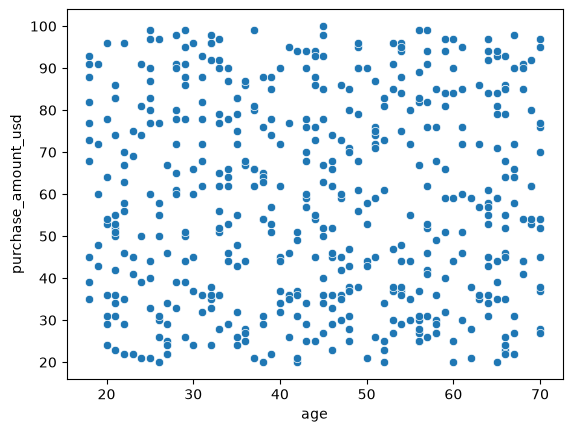

In [18]:
sample_df = df.sample(n=500, random_state=42)
sns.scatterplot(
    data=sample_df,
    x="age",
    y="purchase_amount_usd"
)

Based on the previous EDA process and this, the scatter plot between age and purchase amount does not show a clear pattern. To test this, I will perform a statistical test to see if there's difference.

### Hypotheses

***Question***: 
Is there a statistically significant association between age and purchase amount?

($H_0$)

There is no statistically significant relationship between age and purchase amount.

($H_1$)

There is a statistically significant relationship between age and purchase amount.

### Test Selection

Both `age` and `purchase_amount_usd` are numerical variables. The EDA scatter plot did not show a clear linear pattern between the two variables.

Spearman's correlation was selected because the analysis focuses on whether age and purchase amount have a monotonic association.

The EDA did not show a clear linear relationship, so Spearman's correlation provides a suitable non-parametric measure of monotonic association without requiring a linear relationship between the variables.

### Results

In [25]:
corr, p_value = spearmanr(
    df["age"],
    df["purchase_amount_usd"]
)
print("Spearman correlation(ρ): ", round(corr, 2))
print("P Value                : ", round(p_value, 2))

Spearman correlation(ρ):  -0.01
P Value                :  0.51


### Interpretation

The Spearman correlation between age and purchase amount is -0.01, showing almost no relationship. With a p-value of 0.51 (which is > 0.05), we don't have enough evidence to say that age associated with purchase amount.

Age does not appear to be a strong indicator of purchase amount in the observed customer data. Therefore, customer age alone may not be useful for differentiating customers based on purchase value. In short, the analysis shows that we fail to reject the null hypothesis ($H_0$). 

## 7. Gender vs Purchase Amount

In [30]:
gender_summary = df.groupby("gender")['purchase_amount_usd'].agg(
    ["count", "mean", "median", "std"]
)

gender_summary.T

gender,Female,Male
count,1248.000000,2652.000000
mean,60.249199,59.536199
median,60.000000,60.000000
std,23.420556,23.809976


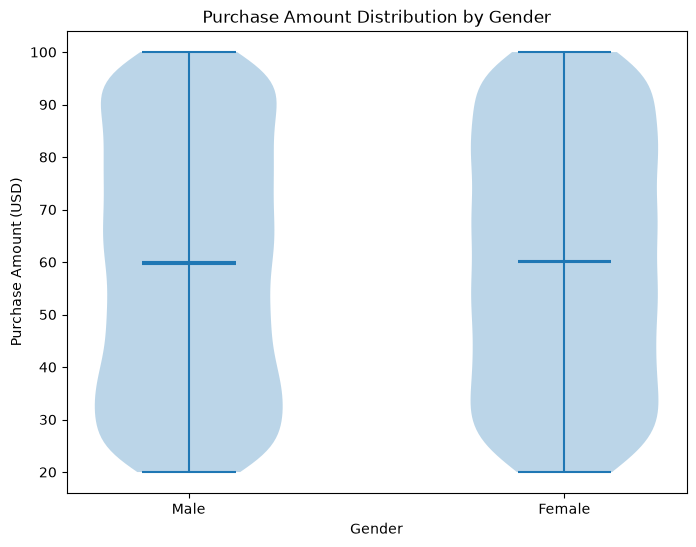

In [31]:
male = df.loc[df['gender'] == "Male", "purchase_amount_usd"]
female = df.loc[df['gender'] == "Female", "purchase_amount_usd"]

plt.figure(figsize=(8, 6))

plt.violinplot(
    [male, female],
    showmeans=True,
    showmedians=True
)

plt.xticks([1, 2], ["Male", "Female"])
plt.xlabel("Gender")
plt.ylabel("Purchase Amount (USD)")
plt.title("Purchase Amount Distribution by Gender")

plt.show()

In [32]:
male.var(), female.var()

(np.float64(566.9149471470682), np.float64(548.5224532467665))

In [33]:
male.std(), female.std()

(np.float64(23.809975790560312), np.float64(23.42055621130221))

The purchase amount distributions for male and female customers appear broadly spread across the observed range. Both groups show similar central tendencies around USD 60, with no major visual difference in their overall distributions.

### Hypotheses

($H_0$) 

There is no difference in purchase amount between male and female customers.

($H_1$) 

There is a difference in purchase amount between male and female customers.

### Test Selection

`gender` is a categorical variable with two independent groups, while `purchase_amount_usd` is a numerical variable. Therefore, the analysis requires a statistical test to compare purchase amounts between two independent groups.

Here, I want to compare the average purchase amounts between male and female customers. Since these two groups are independent of each other, I chose an independent t-test to check if there is a significant difference in their average purchase amounts.

The violin plot shows broadly similar distributions across the two groups. An independent samples t-test is therefore considered appropriate for comparing the mean purchase amount between male and female customers.

Welch's t-test was selected because it does not assume equal variances between the two groups. This makes it more appropriate when group variances may differ and avoids relying on the equal-variance assumption required by the standard Student's t-test.

### Results

In [40]:
t_stat, p_value = ttest_ind(
    male,
    female,
    equal_var=False
)

print("Welch's t-statistic:", round(t_stat, 2))
print("p-value            :", round(p_value, 2))

Welch's t-statistic: -0.88
p-value            : 0.38


### Effect Size

Cohen's D Formula

The pooled standard deviation is calculated as:

$$
s_p =
\sqrt{
\frac{
(n_1-1)s_1^2 + (n_2-1)s_2^2
}{
n_1+n_2-2
}}
$$

Cohen's d is then calculated as:

$$
d = \frac{M_1-M_2}{s_p}
$$

In [43]:
n1 = len(male)
n2 = len(female)

m1 = male.mean()
m2 = female.mean()

sd1 = male.std()
sd2 = female.std()

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (m1 - m2) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: -0.03010203470917683


### Interpretation

Fail to reject $H_0$. The results provide insufficient evidence of a difference in mean purchase amount between male and female customers (Welch's t-test, p = 0.38). The effect size was negligible (Cohen's d = -0.030), indicating that the observed difference is also very small in practical terms.

From a business perspective, male and female customers have similar purchase values in this dataset. Therefore, gender alone may not be particularly useful for distinguishing customers based on their purchase amount.

## 8. Previous Purchases vs Purchase Amount

In [47]:
df[[
    "previous_purchases",
    "purchase_amount_usd"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
previous_purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0
purchase_amount_usd,3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0


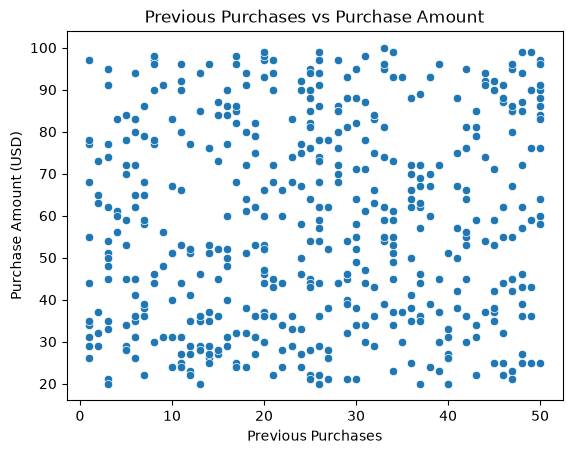

In [48]:
sns.scatterplot(
    data=df.sample(500, random_state=42),
    x="previous_purchases",
    y="purchase_amount_usd"
)

plt.title("Previous Purchases vs Purchase Amount")
plt.xlabel("Previous Purchases")
plt.ylabel("Purchase Amount (USD)")
plt.show()

The scatter plot between previous purchases and purchase amount does not show a clear pattern. To test this, I will perform a statistical test to see if there's difference.

### Hypotheses

($H_0$)

There is no monotonic association between previous purchases and purchase amount.

($H_1$)

There is a monotonic association between previous purchases and purchase amount.

### Test Selection

Both `previous_purchases` and `purchase_amount_usd` are numerical variables.

Spearman's rank correlation is used to assess whether there is a monotonic association between previous purchases and purchase amount.

This approach is appropriate when the relationship does not need to be assumed as linear and provides a non-parametric measure of the strength and direction of a monotonic relationship.

### Result

In [54]:
rho, p_value = spearmanr(
    df["previous_purchases"],
    df["purchase_amount_usd"]
)

print(f"Spearman correlation: {rho:.3f}")
print(f"p-value: {p_value:.3f}")

Spearman correlation: 0.008
p-value: 0.604


### Interpretation

The p-value of 0.604 is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis.

There is insufficient statistical evidence of a monotonic association between previous purchases and purchase amount.

The Spearman correlation coefficient (ρ = 0.008) indicates a negligible relationship between the two variables, with virtually no monotonic association observed in the dataset.

Previous purchase history does not appear to be a strong differentiator of purchase amount in this dataset.

Customers with more previous purchases do not necessarily generate higher purchase amounts. Therefore, previous purchase count alone may 
not be sufficient to identify higher-value customers.

##  9. Region vs Purchase Amount

In [58]:
region_summary = (
    df.groupby("region")["purchase_amount_usd"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean", ascending=False)
)

region_summary.T

region,West,Midwest,Northeast,South
count,1018.000000,937.000000,674.000000,1271.000000
mean,61.187623,59.321238,59.247774,59.225020
median,62.000000,60.000000,59.000000,58.000000
std,23.492654,24.104214,23.245624,23.740023


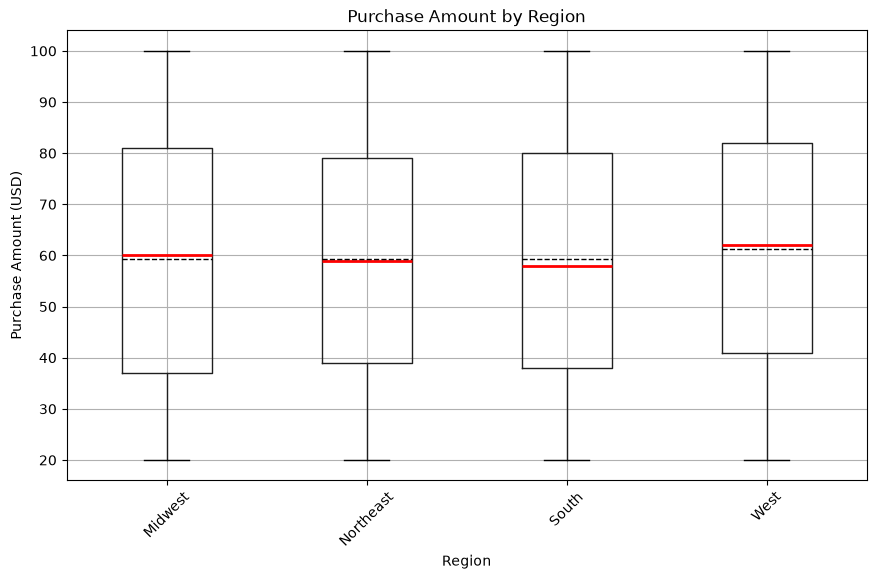

In [59]:
df.boxplot(
    column="purchase_amount_usd",
    by="region",
    figsize=(10, 6),
    medianprops={'color': 'red', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'black'}
)

plt.title("Purchase Amount by Region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Purchase Amount (USD)")
plt.xticks(rotation=45)
plt.show()

As shown in the box plot above, the previous EDA indicates that each region has very similar mean purchase amounts. Now, I want to check if the purchase amounts differ across regions and whether there is enough evidence to state that the mean purchase amount is not equal across all regions or at least one region has a different mean purchase amount.

### Hypotheses

($H_0$)

The mean purchase amount is equal across all regions.

($H_1$) 

At least one region has a different mean purchase amount.

### Test Selection

`region` is a categorical variable with more than two independent groups, while `purchase_amount_usd` is a numerical variable. Therefore, a method for comparing means across multiple groups is required.

A standard one-way ANOVA assumes that the variances across groups are equal. Since equal variance is not assumed in this analysis, Welch's ANOVA is used
because it is more robust when group variances and/or group sizes differ.

Welch's ANOVA is therefore selected to test whether there is sufficient evidence that the mean purchase amount differs across regions.

### Result

In [66]:
welch_region = pg.welch_anova(
    data=df,
    dv="purchase_amount_usd",
    between="region"
)

welch_region

,Source,ddof1,ddof2,F,p_unc,np2
0,region,3,1982.106359,1.679397,0.169392,0.001278


### Interpretation

The p-value of 0.169 is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis.

There is insufficient evidence to conclude that mean purchase amount differs across regions. The very small effect size (partial η² = 0.0013)
also indicates that the observed differences between regions are small in practical terms.

A post-hoc analysis was not performed because the overall Welch's ANOVA was not statistically significant (p = 0.169). Therefore, there was insufficient evidence to conclude that mean purchase amount differs across regions, and there was no overall evidence requiring further pairwise comparison. Fail to reject $H_0$

Based on this dataset, region does not appear to be a strong differentiator of purchase amount. Therefore, regional differences in purchase value alone do not provide strong evidence for prioritizing marketing efforts in one region over another.

## 10. Age Group vs Purchase Amount

In [70]:
age_group_summary = (
    df.groupby("age_group")["purchase_amount_usd"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean", ascending=False)
)

age_group_summary.T

age_group,45-54,18-24,25-34,65-70,35-44,55-64
count,752.000000,486.000000,755.000000,427.000000,729.000000,751.000000
mean,60.332447,60.201646,60.132450,59.704918,59.620027,58.716378
median,60.000000,61.500000,61.000000,60.000000,59.000000,58.000000
std,23.986983,23.932820,23.294299,24.527594,23.479993,23.362950


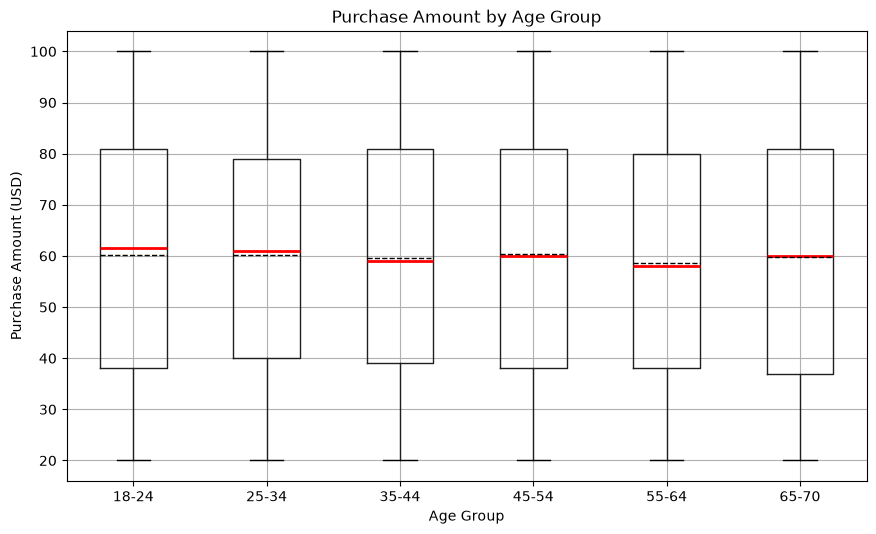

In [71]:
df.boxplot(
    column="purchase_amount_usd",
    by="age_group",
    figsize=(10, 6),
    medianprops={'color': 'red', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'black'}
)

plt.title("Purchase Amount by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount (USD)")
plt.show()

### Hypotheses

($H_0$) 

The mean purchase amount is the same across all age groups.

($H_1$) 

At least one age group has a different mean purchase amount.

### Test Selection

`age_group` is a categorical variable with more than two independent groups, while `purchase_amount_usd` is a numerical variable. Therefore, an ANOVA-based approach is appropriate for comparing mean purchase amounts across age groups

Welch's ANOVA is selected instead of standard one-way ANOVA because it does not require the assumption of equal variances across groups and is more robust when group variances or sample sizes differ.

### Result

In [77]:
welch_age_group = pg.welch_anova(
    data=df,
    dv="purchase_amount_usd",
    between="age_group"
)

welch_age_group

,Source,ddof1,ddof2,F,p_unc,np2
0,age_group,5,1674.344994,0.461936,0.804774,0.000585


### Post-hoc

### Effect size

### Interpretation

The p-value of 0.805 is greater than the significance level of 0.05, so we fail to reject the null hypothesis.

There is insufficient evidence to conclude that mean purchase amount differs across age groups. The effect size was also very small (partial η² = 0.000585), indicating that the observed differences between age groups are negligible in practical terms.

Since the overall Welch's ANOVA was not statistically significant, a post-hoc Games-Howell analysis was not performed.

From a business perspective, the age groups in this dataset do not appear to differ meaningfully in purchase amount. Therefore, age group alone may not be a strong basis for differentiating customers by purchase value.

## 11. Product Category vs Purchase Amount

In [83]:
category_summary = (
    df.groupby("category")["purchase_amount_usd"]
      .agg(["count", "mean", "median", "std"])
      .sort_values("mean", ascending=False)
)

category_summary.T

category,Footwear,Clothing,Accessories,Outerwear
count,599.000000,1737.000000,1240.00000,324.000000
mean,60.255426,60.025331,59.83871,57.172840
median,60.000000,60.000000,60.00000,54.500000
std,23.638439,23.792460,23.30123,24.590033


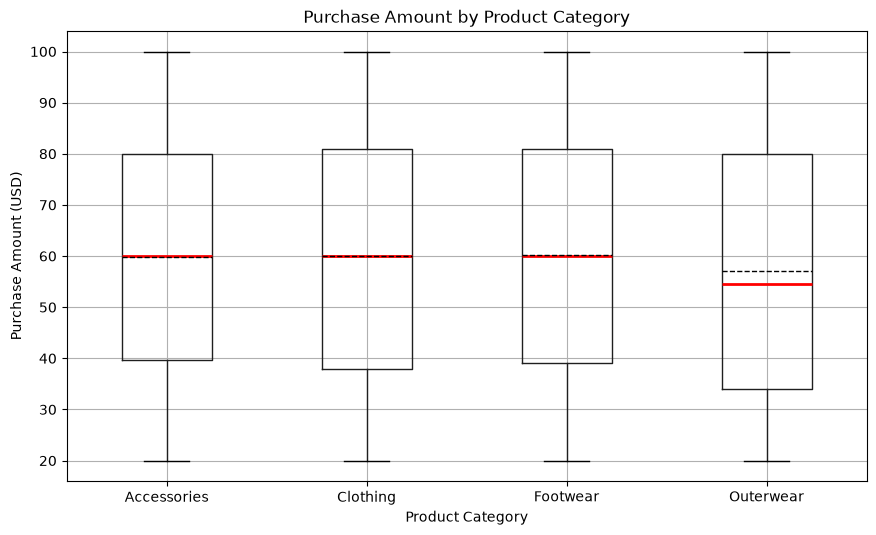

In [84]:
df.boxplot(
    column="purchase_amount_usd",
    by="category",
    figsize=(10, 6),
    medianprops={'color': 'red', 'linewidth': 2},
    showmeans=True,
    meanline=True,
    meanprops={'color': 'black'}
)

plt.title("Purchase Amount by Product Category")
plt.suptitle("")
plt.xlabel("Product Category")
plt.ylabel("Purchase Amount (USD)")
plt.show()

From the analysis above, we can see that the mean purchase amount across each category is quite similar. Now, I want to examine whether purchase amounts differ across product categories and whether there is sufficient evidence to state that the mean purchase amounts are not equal for every category

### Hypotheses

($H_0$)

The mean purchase amount is equal across all product categories.

($H_1$) 

At least one product category has a different mean purchase amount.

### Test Selection

`category` is a categorical variable with more than two independent groups, while `purchase_amount_usd` is a numerical variable. Therefore, an ANOVA-based approach is appropriate for comparing mean purchase amounts across product categories.

Welch's ANOVA is selected because it does not require the assumption of equal variances across groups and is more robust when group variances or sample sizes differ.

### Result

In [91]:
import pingouin as pg

welch_category = pg.welch_anova(
    data=df,
    dv="purchase_amount_usd",
    between="category"
)

welch_category

,Source,ddof1,ddof2,F,p_unc,np2
0,category,3,1141.852476,1.357429,0.254338,0.001118


### Interpretation

The p-value of 0.254 is greater than the significance level of 0.05, so we fail to reject the null hypothesis.

There is insufficient evidence to conclude that mean purchase amount differs across product categories. The effect size was also very small
(partial η² = 0.001118), indicating that the observed differences between product categories are negligible in practical terms.

Since the overall Welch's ANOVA was not statistically significant, a post-hoc Games-Howell analysis was not performed.


Product category does not appear to be a strong differentiator of purchase amount in this dataset. Therefore, differences in average purchase value across categories alone may not provide a strong basis for prioritizing one category over another based on purchase amount.

## 12. Discount Usage vs Purchase Amount

In [95]:
discount_summary = (
    df.groupby("discount_applied")["purchase_amount_usd"]
      .agg(["count", "mean", "median", "std"])
)

discount_summary.T

discount_applied,No,Yes
count,2223.000000,1677.000000
mean,60.130454,59.279070
median,60.000000,60.000000
std,23.740327,23.610697


### Hypotheses

($H_0$) 

There is no difference in mean purchase amount between customers who used a discount and those who did not.

($H_1$)

There is a difference in mean purchase amount between customers who used a discount and those who did not.

### Test Selection

`discount_applied` is a categorical variable with two independent groups, while `purchase_amount_usd` is a numerical variable. Therefore, a
two-sample comparison is appropriate.

Welch's t-test is selected because the population standard deviation is unknown and the test does not require the two groups to have equal
variances.

### Result

In [101]:
discount_yes = df.loc[df['discount_applied'] == "Yes", "purchase_amount_usd"]

discount_no = df.loc[df['discount_applied'] == "No", "purchase_amount_usd"]

t_stat, p_value = ttest_ind(
    discount_yes,
    discount_no,
    equal_var=False
)

print("Welch's t-statistic:", t_stat)
print("p-value:", p_value)

Welch's t-statistic: -1.1122316185807992
p-value: 0.26611244488939256


### Effect Size

Cohen's D Formula

The pooled standard deviation is calculated as:

$$
s_p =
\sqrt{
\frac{
(n_1-1)s_1^2 + (n_2-1)s_2^2
}{
n_1+n_2-2
}}
$$

Cohen's d is then calculated as:

$$
d = \frac{M_1-M_2}{s_p}
$$

In [104]:
n1 = len(discount_yes)
n2 = len(discount_no)

mean1 = discount_yes.mean()
mean2 = discount_no.mean()

sd1 = discount_yes.std()
sd2 = discount_no.std()

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: -0.03594663914655503


### Interpretation

The p-value of 0.266 is greater than the significance level of 0.05, so we fail to reject the null hypothesis.

There is insufficient evidence to conclude that mean purchase amount differs between customers who used a discount and those who did not. The effect size was also negligible (Cohen's d = -0.036), indicating that the observed difference is very small in practical terms.

From a business perspective, discount usage does not appear to be a strong differentiator of purchase amount in this dataset. Therefore, discount usage alone may not be sufficient to identify customers with higher purchase value.

## 13. Subscription Status vs Purchase Amount

In [108]:
subscription_summary = (
    df.groupby("subscription_status")["purchase_amount_usd"]
      .agg(["count", "mean", "median", "std"])
)

subscription_summary.T

subscription_status,No,Yes
count,2847.000000,1053.000000
mean,59.865121,59.491928
median,60.000000,60.000000
std,23.775199,23.449914


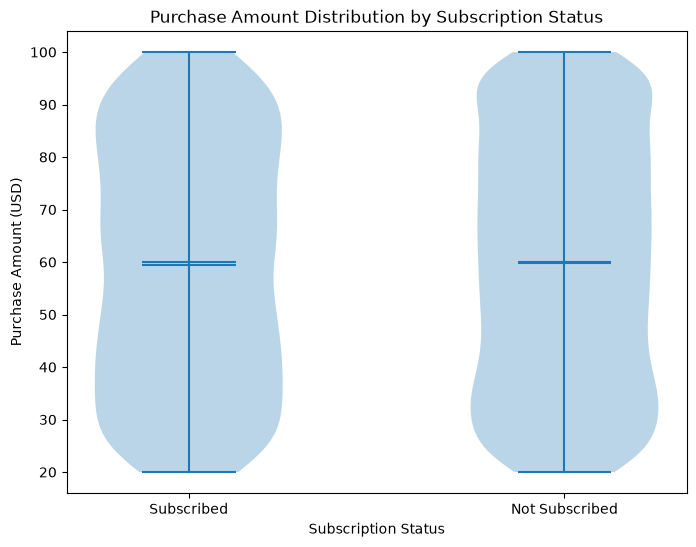

In [109]:
subscribed_yes = df.loc[df['subscription_status'] == "Yes", "purchase_amount_usd"]
subscribed_no = df.loc[df['subscription_status'] == "No", "purchase_amount_usd"]

plt.figure(figsize=(8, 6))

plt.violinplot(
    [subscribed_yes, subscribed_no],
    showmeans=True,
    showmedians=True
)

plt.xticks([1, 2], ["Subscribed", "Not Subscribed"])
plt.xlabel("Subscription Status")
plt.ylabel("Purchase Amount (USD)")
plt.title("Purchase Amount Distribution by Subscription Status")

plt.show()

In [110]:
subscribed_yes.var(), subscribed_no.var()

(np.float64(549.8984613940255), np.float64(565.2600866244529))

In [111]:
subscribed_yes.std(), subscribed_no.std()

(np.float64(23.449913888840307), np.float64(23.775198981805662))

The violin plot above shows that the mean purchase amounts between subscribed and non subscribed customers are quite similar. Now, I want to formally test and measure the difference between the mean purchase amounts of these two groups.

### Hypotheses

($H_0$)

There is no difference in mean purchase amount between subscribed and non subscribed customers.

($H_1$)

There is a difference in mean purchase amount between subscribed and non-subscribed customers


### Test Selection

`subscription_status` is a categorical variable with two independent groups, while `purchase_amount_usd` is a numerical variable.

Therefore, a test for comparing the means of two independent groups is appropriate.

Welch's t-test is used because equal variances between the two groups are not assumed.

### Result

In [118]:
t_stat, p_value = ttest_ind(
    subscribed_yes,
    subscribed_no,
    equal_var=False
)

print("Welch's t-statistic:", round(t_stat, 2))
print("p-value            :", round(p_value, 2))

Welch's t-statistic: -0.44
p-value            : 0.66


### Effect Size

Cohen's D Formula

The pooled standard deviation is calculated as:

$$
s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}
$$

Cohen's d is then calculated as:

$$
d = \frac{M_1-M_2}{s_p}
$$

In [121]:
n1 = len(subscribed_yes)
n2 = len(subscribed_no)

m1 = subscribed_yes.mean()
m2 = subscribed_no.mean()

sd1 = subscribed_yes.std()
sd2 = subscribed_no.std()

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (m1 - m2) / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: -0.01575463147895725


### Interpretation

The p-value of 0.66 is greater than the significance level of 0.05, so we fail to reject the null hypothesis.

There is insufficient evidence to conclude that mean purchase amount differs between subscribed and non-subscribed customers.

The effect size was also negligible (Cohen's d = -0.016), indicating that the observed difference is very small in practical terms.

From a business perspective, subscription status does not appear to be a strong differentiator of purchase amount in this dataset. Therefore,
subscription status alone may not be sufficient to identify customers with higher purchase value.

## 14. Subscription Status vs Discount Usage

### Hypotheses

($H_0$)

Subscription status and discount usage are independent.

($H_1$) 

Subscription status and discount usage are associated.

### Test Selection

Both `subscription_status` and `discount_applied` are categorical variables. Therefore, the analysis focuses on whether the two variables are statistically independent.

A Chi-square test of independence is used to determine whether discount usage is associated with subscription status.

### Contingency Table

In [130]:
contingency_table = pd.crosstab(
    df["subscription_status"],
    df["discount_applied"]
)

contingency_table

discount_applied,No,Yes
subscription_status,,
No,2223,624
Yes,0,1053


In [131]:
discount_rate = pd.crosstab(
    df["subscription_status"],
    df["discount_applied"],
    normalize="index"
) * 100

discount_rate

discount_applied,No,Yes
subscription_status,,
No,78.082192,21.917808
Yes,0.000000,100.000000


### Chi-square / Alternative

In [133]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1908.9213651509538
p-value: 0.0
Degrees of freedom: 1


In [187]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_table

discount_applied,No,Yes
subscription_status,,
No,1622.79,1224.21
Yes,600.21,452.79


### Effect Size

In [135]:
n = contingency_table.to_numpy().sum()
min_dimension = min(contingency_table.shape) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.6996191940658666


### Interpretation

The Chi-square test produced a p-value below the 0.05 significance level, so we reject the null hypothesis.

There is strong evidence of an association between subscription status and discount usage (χ² = 1908.921, p < 0.001).

The Cramer's V of 0.700 indicates a strong association between the two variables. This suggests that discount usage differs substantially
between subscription groups in this dataset.

From a business perspective, subscription status and discount usage appear to be strongly related in this dataset. This suggests that discount usage may be closely connected with the subscription program and could be considered when evaluating subscription engagement and promotional strategies.

## 15. Statistical Results Summary

| Analytical Question                  | Analysis                         | Statistical Method   | p-value     | Effect Size    | Result          |
|--------------------------------------|----------------------------------|----------------------|------------:|---------------:|-----------------|
| AQ1.  Age → Purchase Amount          | Age vs Purchase Amount           | Spearman correlation | 0.51        | ρ = -0.01      | Not significant |
| AQ1. Gender → Purchase Amount        | Gender vs Purchase Amount        | Welch's t-test       | 0.38        | d = -0.030     | Not significant |
| AQ2. Age Group → Purchase Amount     | Age Group vs Purchase Amount     | Welch's ANOVA        | 0.805       | η²p = 0.000585 | Not significant |
| AQ2. Region → Purchase Amount        | Region vs Purchase Amount        | Welch's ANOVA        | 0.169       | η²p = 0.001278 | Not significant |
| AQ3. Category → Purchase Amount      | Category vs Purchase Amount      | Welch's ANOVA        | 0.254       | η²p = 0.001118 | Not significant |
| AQ4. Discount → Purchase Amount      | Discount vs Purchase Amount      | Welch's t-test       | 0.266       | d = -0.036     | Not significant |
| AQ5. Subscription → Purchase Amount  | Subscription vs Purchase Amount  | Welch's t-test       | 0.66        | d = -0.0157    | Not significant |
| AQ6. Subscription ↔ Discount         | Subscription vs Discount         | Chi$^2$-test         | <0.001      | V = 0.700      | Significant     |

## 16. Statistical Findings

### Customer Characteristics and Purchase Value

The analysis did not find sufficient evidence that age, gender, or previous purchases are associated with higher purchase amount.

Age and previous purchases showed negligible monotonic associations with purchase amount, while gender did not show a statistically significant
difference in mean purchase amount.

### Customer Groups and Purchase Value

No statistically significant differences in mean purchase amount were identified across age groups or regions. Product categories also did not show statistically significant differences in mean purchase amount.

### Promotional and Subscription Behavior

Discount usage did not show a statistically significant difference in purchase amount.

However, subscription status showed a strong association with discount usage (χ² = 1908.921, p < 0.001, Cramer's V = 0.700). This indicates that discount usage differs substantially between subscription groups in this dataset.

## 17. Limitations

### Dataset Limitations

- The dataset is synthetic and its data generating process is not fully documented.
- The underlying population and sampling process are unknown.
- The findings should therefore be interpreted as evidence within the observed dataset rather than as definitive conclusions about all TrendOne customers.

### Temporal Limitation

- The dataset does not contain transaction dates or timestamps.
- Time-based retention, cohort analysis, and time to repeat purchase analysis cannot be reliably performed.

### Statistical Limitations

- Statistical tests assess associations or differences and do not establish causality.
- Non-significant results indicate insufficient evidence of a difference or association, rather than proof that no relationship exists.
- The analysis relies on the available variables and cannot account for potentially relevant factors that are not present in the dataset.

## 18. Summary & Next Steps

The statistical analysis evaluated the relationships and differences identified during the EDA stage across customer characteristics, customer groups, product categories, promotional usage, and subscription status.

Most analyses did not provide sufficient statistical evidence of differences in purchase amount across the examined customer characteristics and groups. However, subscription status showed a strong association with discount usage, indicating that this relationship warrants further business investigation.

The results will be carried forward to the Customer Segmentation and SQL Analytics stages to further explore customer behavior and identify
patterns that may support business recommendations.

### Next Steps

- Develop customer segments based on relevant behavioral characteristics.
- Validate key findings using SQL-based analysis.
- Explore the results through the Power BI dashboard.
- Combine statistical findings with segmentation and descriptive
  analysis to develop business recommendations.